In [1]:
# gw-gain-main.ipynb

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import anndata as ad
import logging
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import sys

In [4]:
in_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/rdr/base/gw-gain/pp"
out_stat_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/rdr/base/gw-gain/stats"
out_fig_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/rdr/base/gw-gain/figures"

In [5]:
utils_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/rdr/base/scripts"
sys.path.append(utils_dir)
from ubase import *
from urdr import *

In [6]:
os.makedirs(out_stat_dir, exist_ok = True)
os.makedirs(out_fig_dir, exist_ok = True)

In [7]:
cw_prefix = 'cw-'
gw_prefix = 'gw-'

dpi = 300

In [8]:
blue = '#0072B2'
orange = '#E69F00'
green = '#009E73'
red = '#D55E00'     # Vermillion

def_color = blue

In [9]:
tool_labels = ['seed_N', 'stCNASim-rs_N', 'scReadSim-cna_N', 'stCNASim-rs_T', 'scReadSim-cna_T']
tool_palette = {
    'seed_N': orange,
    'stCNASim-rs_N': '#56B4E9',
    'scReadSim-cna_N': green,
    'stCNASim-rs_T': '#F0E442',
    'scReadSim-cna_T': blue
}

# Load Data

In [10]:
seed_normal_fn = os.path.join(in_dir, "seed_normal.h5ad")
rs_normal_fn = os.path.join(in_dir, "rs_normal.h5ad")
rs_tumor_fn = os.path.join(in_dir, "rs_tumor.h5ad")
scrs_normal_fn = os.path.join(in_dir, "scrs_normal.h5ad")
scrs_tumor_fn = os.path.join(in_dir, "scrs_tumor.h5ad")

In [11]:
seed_normal = ad.read_h5ad(seed_normal_fn)
print(seed_normal)

rs_normal = ad.read_h5ad(rs_normal_fn)
print(rs_normal)

rs_tumor = ad.read_h5ad(rs_tumor_fn)
print(rs_tumor)

scrs_normal = ad.read_h5ad(scrs_normal_fn)
print(scrs_normal)

scrs_tumor = ad.read_h5ad(scrs_tumor_fn)
print(scrs_tumor)

AnnData object with n_obs × n_vars = 600 × 2301
    obs: 'cell', 'cell_type'
    var: 'gene_id', 'gene', 'chrom', 'start', 'end', 'strand', 'feature'
AnnData object with n_obs × n_vars = 600 × 2301
    obs: 'cell', 'cell_type'
    var: 'gene_id', 'gene', 'chrom', 'start', 'end', 'strand', 'feature'
AnnData object with n_obs × n_vars = 600 × 2301
    obs: 'cell', 'cell_type'
    var: 'gene_id', 'gene', 'chrom', 'start', 'end', 'strand', 'feature'
AnnData object with n_obs × n_vars = 600 × 2301
    obs: 'cell', 'cell_type'
    var: 'gene_id', 'gene', 'chrom', 'start', 'end', 'strand', 'feature'
AnnData object with n_obs × n_vars = 600 × 2301
    obs: 'cell', 'cell_type'
    var: 'gene_id', 'gene', 'chrom', 'start', 'end', 'strand', 'feature'


# Cell-wise Metrics

In [12]:
mv = get_cw_metrics_group(
    X_lst = [seed_normal.X, rs_normal.X, scrs_normal.X, rs_tumor.X, scrs_tumor.X],
    X_names = tool_labels,
    id_lst = [seed_normal.obs['cell'].to_numpy(), rs_normal.obs['cell'].to_numpy(), scrs_normal.obs['cell'].to_numpy(),
             rs_tumor.obs['cell'].to_numpy(), scrs_tumor.obs['cell'].to_numpy()],
    metrics = ["lib_size", "zero_prop"]
)
mv = mv.rename(columns = dict(X_name = 'group'))
mv

,lib_size,zero_prop,group,cell
0,644,0.900043,seed_N,AAACAAGTATCTCCCA-1
1,1310,0.850065,seed_N,AAACATTTCCCGGATT-1
2,813,0.885267,seed_N,AAACCGTTCGTCCAGG-1
3,1018,0.877010,seed_N,AAACCTAAGCAGCCGG-1
4,427,0.928727,seed_N,AAACGGGCGTACGGGT-1
...,...,...,...,...
2995,1074,0.870491,scReadSim-cna_T,TTGTAAGTAGTATGGC-1
2996,602,0.900043,scReadSim-cna_T,TTTAAACCGGCGGTAA-1
2997,1234,0.872664,scReadSim-cna_T,TTTAGTGCTGTCTAGG-1
2998,875,0.886136,scReadSim-cna_T,TTTGACACTTCTATTC-1


In [13]:
tmp = mv[["group", "cell", "lib_size", "zero_prop"]]

tmp.to_csv(
    os.path.join(out_stat_dir, cw_prefix + "metric_values.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

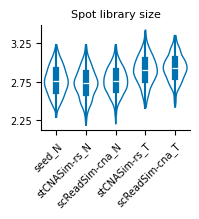

In [14]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv['group']
y = mv['lib_size']
y = np.log10(y + 1)
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = 'box',
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([2.25, 2.75, 3.25])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)

for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Spot library size", fontsize = 8)
plt.tight_layout()
fn = os.path.join(out_fig_dir, cw_prefix + "libsize.png")
fig.savefig(fn, dpi = 300)

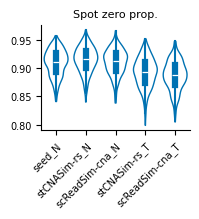

In [15]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv['group']
y = mv['zero_prop']
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = 'box',
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0.8, 0.85, 0.9, 0.95])
#ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Spot zero prop.", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, cw_prefix + "zero_prop.png")
fig.savefig(fn, dpi = 300)

# Gene-wise Metrics

In [16]:
mv = get_gw_metrics_group(
    X_lst = [seed_normal.X, rs_normal.X, scrs_normal.X, rs_tumor.X, scrs_tumor.X],
    X_names = tool_labels,
    id_lst = [seed_normal.var['feature'].to_numpy(), rs_normal.var['feature'].to_numpy(), scrs_normal.var['feature'].to_numpy(),
             rs_tumor.var['feature'].to_numpy(), scrs_tumor.var['feature'].to_numpy()],
    metrics = ["mean", "var", "cv", "zero_prop"]
)
mv = mv.rename(columns = dict(X_name = 'group'))
mv

,mean,var,cv,zero_prop,group,feature
0,0.000000,0.000000,0.000000,1.000000,seed_N,AC239859.3
1,0.126667,0.127289,2.816650,0.880000,seed_N,AC239800.2
2,0.020000,0.019600,7.000000,0.980000,seed_N,AC239800.3
3,0.000000,0.000000,0.000000,1.000000,seed_N,AC239798.2
4,0.000000,0.000000,0.000000,1.000000,seed_N,AC246680.1
...,...,...,...,...,...,...
11500,0.016667,0.016389,7.681146,0.983333,scReadSim-cna_T,ZNF250
11501,0.070000,0.085100,4.167415,0.940000,scReadSim-cna_T,ZNF16
11502,0.000000,0.000000,0.000000,1.000000,scReadSim-cna_T,AF235103.1
11503,0.000000,0.000000,0.000000,1.000000,scReadSim-cna_T,ZNF252P-AS1


In [17]:
tmp = mv[["group", "feature", "mean", "var", "cv", "zero_prop"]]

tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "metric_values.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

In [18]:
np.log10(mv['mean'].min() + 1), np.log10(mv['mean'].max() + 1)

(0.0, 2.2355915665184303)

## Single Metric

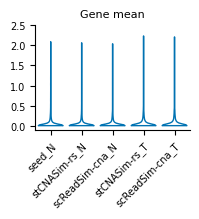

In [19]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv['group']
y = mv['mean']
y = np.log10(y + 1)
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = None,
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 0.5, 1, 1.5, 2, 2.5])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Gene mean", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "mean.png")
fig.savefig(fn, dpi = 300)

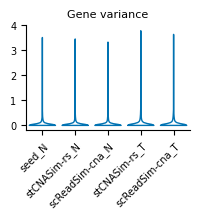

In [20]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv['group']
y = mv['var']
y = np.log10(y + 1)
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = None,
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 1, 2, 3, 4])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Gene variance", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "variance.png")
fig.savefig(fn, dpi = 300)

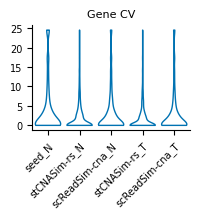

In [21]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv['group']
y = mv['cv']
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = None,
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 5, 10, 15, 20, 25])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Gene CV", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "cv.png")
fig.savefig(fn, dpi = 300)

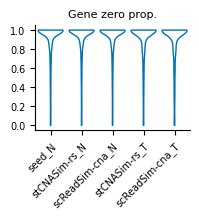

In [22]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv['group']
y = mv['zero_prop']
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = None,
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Gene zero prop.", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "zero_prop.png")
fig.savefig(fn, dpi = 300)

### Percentage of genes within specific ranges of zero proportions

In [23]:
st_zeroprop = stat_stack_zeroprop(
    data = mv, 
    metric = "zero_prop",
    group = "group", 
    cutoffs = [.9, .99, 1.01], 
    labels = ["[0, 0.9)", "[0.9, 0.99)", "[0.99, 1]"]
)
print(st_zeroprop)


tmp = st_zeroprop[["group", "cutoff", "label", "percent"]]
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "perc-of-genes-on-zero_prop.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

              group  level_1  cutoff        label    percent
0            seed_N        0    0.90     [0, 0.9)  23.424598
1            seed_N        1    0.99  [0.9, 0.99)  16.862234
2            seed_N        2    1.01    [0.99, 1]  59.713168
3     stCNASim-rs_N        0    0.90     [0, 0.9)  22.381573
4     stCNASim-rs_N        1    0.99  [0.9, 0.99)  17.514124
5     stCNASim-rs_N        2    1.01    [0.99, 1]  60.104302
6   scReadSim-cna_N        0    0.90     [0, 0.9)  22.729248
7   scReadSim-cna_N        1    0.99  [0.9, 0.99)  17.992177
8   scReadSim-cna_N        2    1.01    [0.99, 1]  59.278575
9     stCNASim-rs_T        0    0.90     [0, 0.9)  25.945241
10    stCNASim-rs_T        1    0.99  [0.9, 0.99)  16.123425
11    stCNASim-rs_T        2    1.01    [0.99, 1]  57.931334
12  scReadSim-cna_T        0    0.90     [0, 0.9)  26.988266
13  scReadSim-cna_T        1    0.99  [0.9, 0.99)  16.036506
14  scReadSim-cna_T        2    1.01    [0.99, 1]  56.975228


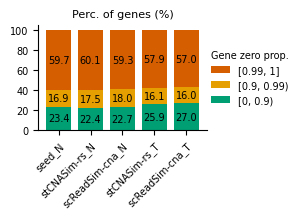

In [24]:
data = st_zeroprop
x, y, hue = 'group', 'percent', 'label'
min_v = 0
font_size = 7
colors = [green, orange, red]

# prepare data.
df = long2wide(data, index = x, columns = hue, values = y)
df[x] = df.index
hue_groups = data[hue].unique()
cumsum = np.array([0.0] * df.shape[0])

# plot.
fig = plt.figure(figsize = (3.1, 2.3))

for i, h in enumerate(hue_groups):
    if i == 0:
        plt.bar(df[x], df[h], label = h, color = colors[i])
    else:
        ax = plt.gca()
        ax.bar(df[x], df[h], label = h, bottom = cumsum, color = colors[i])
    cumsum += df[h]
        
for c in ax.containers:
    labels = [str(round(v.get_height(), 1))    \
                if v.get_height() > min_v else '' for v in c]
    ax.bar_label(c, label_type = 'center', labels = labels, 
                    fontsize = font_size, color = 'black')

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_ylabel("")
ax.set_xlabel("")

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles = handles[::-1],
    labels = labels[::-1],
    title = "Gene zero prop.",
    loc = 'center left',
    bbox_to_anchor = [0.97, 0.5],
    title_fontsize = font_size,
    fontsize = font_size,
    alignment = 'left',
    frameon = False
)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Perc. of genes (%)", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "perc-of-genes-on-zero_prop.png")
fig.savefig(fn, dpi = 300)

## Pair of Metrics

In [25]:
st_smooth = stat_smooth(
    x = "mean",
    y = "zero_prop",
    data = mv, 
    k = 100,
    group = "group",
    log_scale = (True, False),
    ncores = 20
)
print(st_smooth)

st_smooth.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "zero_prop-vs-mean.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

processing group 'seed_N' ...
processing group 'stCNASim-rs_N' ...
processing group 'scReadSim-cna_N' ...
processing group 'stCNASim-rs_T' ...
processing group 'scReadSim-cna_T' ...
                 group      mean  zero_prop
0               seed_N  0.000000   1.000000
1               seed_N  0.000000   1.000000
2               seed_N  0.000000   1.000000
3               seed_N  0.000000   1.000000
4               seed_N  0.000000   1.000000
...                ...       ...        ...
11500  scReadSim-cna_T  1.386083   0.023243
11501  scReadSim-cna_T  1.488457   0.013948
11502  scReadSim-cna_T  1.521922   0.011640
11503  scReadSim-cna_T  1.679382   0.004577
11504  scReadSim-cna_T  2.211583   0.000064

[11505 rows x 3 columns]


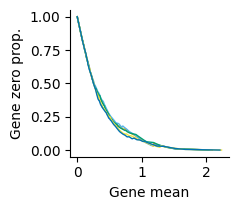

In [26]:
fig = plt.figure(figsize = (2.4, 2.2))
ax = sns.lineplot(
    st_smooth, x = "mean", y = "zero_prop", hue = 'group', 
    legend = False,
    linewidth = 1,
    palette = tool_palette
)
ax.set_xticks([0, 1, 2])
ax.set_xlabel(r"Gene mean")
ax.set_ylabel("Gene zero prop.")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "zero_prop-vs-mean.png")
fig.savefig(fn, dpi = 300)

In [27]:
st_smooth = stat_smooth(
    x = "mean",
    y = "var",
    data = mv,
    k = 100,
    group = "group",
    log_scale = (True, True),
    ncores = 20
)
print(st_smooth)

st_smooth.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "var-vs-mean.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

processing group 'seed_N' ...
processing group 'stCNASim-rs_N' ...
processing group 'scReadSim-cna_N' ...
processing group 'stCNASim-rs_T' ...
processing group 'scReadSim-cna_T' ...
                 group      mean       var
0               seed_N  0.000000  0.000000
1               seed_N  0.000000  0.000000
2               seed_N  0.000000  0.000000
3               seed_N  0.000000  0.000000
4               seed_N  0.000000  0.000000
...                ...       ...       ...
11500  scReadSim-cna_T  1.386083  1.570766
11501  scReadSim-cna_T  1.488457  1.733527
11502  scReadSim-cna_T  1.521922  1.785252
11503  scReadSim-cna_T  1.679382  2.021531
11504  scReadSim-cna_T  2.211583  3.105167

[11505 rows x 3 columns]


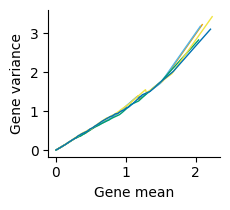

In [28]:
fig = plt.figure(figsize = (2.4, 2.2))
ax = sns.lineplot(
    st_smooth, x = "mean", y = "var", hue = 'group', 
    legend = False,
    linewidth = 1,
    palette = tool_palette
)
ax.set_xticks([0, 1, 2])
ax.set_xlabel(r"Gene mean")
ax.set_ylabel(r"Gene variance")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "var-vs-mean.png")
fig.savefig(fn, dpi = 300)

In [29]:
mv2 = mv[~((mv["mean"] <= 0) & (mv["cv"] <= 0))].copy()

st_smooth = stat_smooth(
    x = "mean",
    y = "cv",
    data = mv2, 
    k = 100,
    group = "group",
    log_scale = (True, False),
    ncores = 20
)
print(st_smooth)

st_smooth.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "cv-vs-mean.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

processing group 'seed_N' ...
processing group 'stCNASim-rs_N' ...
processing group 'scReadSim-cna_N' ...
processing group 'stCNASim-rs_T' ...
processing group 'scReadSim-cna_T' ...
                group      mean         cv
0              seed_N  0.000723  24.474475
1              seed_N  0.000723  24.474475
2              seed_N  0.000723  24.474475
3              seed_N  0.000723  24.474475
4              seed_N  0.000723  24.474475
...               ...       ...        ...
5686  scReadSim-cna_T  1.386083   0.550132
5687  scReadSim-cna_T  1.488457   0.521103
5688  scReadSim-cna_T  1.521922   0.512928
5689  scReadSim-cna_T  1.679382   0.482516
5690  scReadSim-cna_T  2.211583   0.425518

[5691 rows x 3 columns]


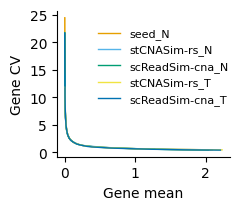

In [30]:
fig = plt.figure(figsize = (2.5, 2.2))
ax = sns.lineplot(
    st_smooth, x = "mean", y = "cv", hue = 'group',
    linewidth = 1,
    palette = tool_palette
)
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles = handles, labels = tool_labels)
sns.move_legend(
    ax, "upper left", title = None, frameon = False,
    bbox_to_anchor = (0.18, 0.95), fontsize = 8
)
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 5, 10, 15, 20, 25])
ax.set_xlabel(r"Gene mean")
ax.set_ylabel("Gene CV")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "cv-vs-mean.png")
fig.savefig(fn, dpi = 300)

## Linear Regression

In [31]:
pairs = [
    ("stCNASim-rs_N", "seed_N"),
    ("scReadSim-cna_N", "seed_N"),
    ("stCNASim-rs_N", "scReadSim-cna_N"),
    ("stCNASim-rs_T", "scReadSim-cna_T")
]

selected_gvars = pd.DataFrame(data = dict(
    x = [p[1] for p in pairs],
    y = [p[0] for p in pairs],
))

In [32]:
st_lr = stat_LR(
    data = mv,
    metric = "mean", group = "group", gvars = selected_gvars, 
    log_scale = True
)
print(st_lr)

tmp = st_lr.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "mean-lr-stat.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

                 x                y         a         b        r2  p_value
0           seed_N    stCNASim-rs_N  0.965766 -0.001077  0.998753      0.0
1           seed_N  scReadSim-cna_N  0.989043 -0.000084  0.980524      0.0
2  scReadSim-cna_N    stCNASim-rs_N  0.957441 -0.000053  0.979289      0.0
3  scReadSim-cna_T    stCNASim-rs_T  0.966451 -0.000700  0.984919      0.0


In [33]:
df_mean = long2wide(mv, columns = 'group', values = 'mean', index = 'feature')
print(df_mean)

tmp = df_mean.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "mean-lr.tsv"), 
    header = True, 
    index = True, 
    sep = "\t"
)

group          seed_N  stCNASim-rs_N  scReadSim-cna_N  stCNASim-rs_T  \
feature                                                                
AC239859.3   0.000000       0.000000         0.000000       0.000000   
AC239800.2   0.126667       0.110000         0.146667       0.188333   
AC239800.3   0.020000       0.013333         0.055000       0.025000   
AC239798.2   0.000000       0.000000         0.000000       0.000000   
AC246680.1   0.000000       0.000000         0.000000       0.000000   
...               ...            ...              ...            ...   
ZNF250       0.016667       0.018333         0.015000       0.020000   
ZNF16        0.041667       0.040000         0.048333       0.073333   
AF235103.1   0.000000       0.000000         0.000000       0.000000   
ZNF252P-AS1  0.000000       0.000000         0.000000       0.000000   
C8orf33      0.205000       0.203333         0.125000       0.325000   

group        scReadSim-cna_T  
feature                       
A

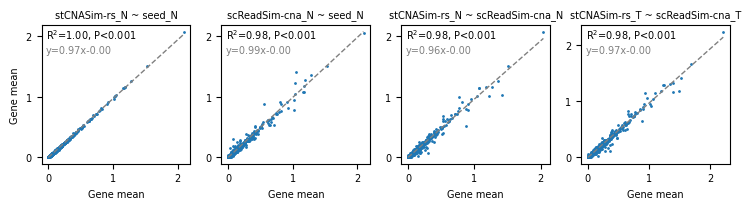

In [34]:
ncols = 4
fig, axs = plt.subplots(nrows = 1, ncols = ncols, figsize = (7.5, 2.2))

pos_r = (.03, .9)
pos_fit = (.03, .8)
fit_kws = dict()
fontsize = 7

columns = np.asarray(df_mean.columns)
df = df_mean[columns].copy()
df = df.map(lambda x: np.log10(x + 1))

gvars = st_lr[['x', 'y']].copy()
x_min, x_max = None, None
cols = np.union1d(gvars['x'], gvars['y'])
for c in cols:
    if x_min is None:
        x_min = df[c].min()
    elif df[c].min() < x_min:
        x_min = df[c].min()
    if x_max is None:
        x_max = df[c].max()
    elif df[c].max() > x_max:
        x_max = df[c].max()
xlims = (x_min, x_max)
    
k = 0
for i in range(gvars.shape[0]):
    ax = axs.flat[k]
    cx = gvars['x'].loc[i]
    cy = gvars['y'].loc[i]
    d = st_lr.loc[(st_lr['x'] == cx) & (st_lr['y'] == cy)]
    assert d.shape[0] == 1
    a = d['a'].iloc[0]
    b = d['b'].iloc[0]
    r2 = d['r2'].iloc[0]
    p_value = d['p_value'].iloc[0]

    x, y = df[cx], df[cy]
    ax.plot(x, y, marker = '.', markersize = 2, linestyle = 'none')
    x_vals = np.linspace(max(ax.get_xlim()[0], np.min(x)), 
                        min(ax.get_xlim()[1], np.max(x)), 100)

    color_fit = fit_kws.get('color', 'gray')
    ax.plot(
        x_vals, a*x_vals+b, 
        linestyle = fit_kws.get('linestyle', '--'), 
        color = color_fit, 
        linewidth = fit_kws.get('linewidth', 1.0)
    )
    equation_str = format_equation(a, b)
    ax.annotate(equation_str, xy = pos_fit, xycoords = ax.transAxes,
                color = color_fit, fontsize = fontsize)
    pv_str = format_pvalue(p_value) 
    ax.annotate(r"R$^2$=%.2f, %s" % (r2, pv_str), xy = pos_r, 
                xycoords = ax.transAxes, fontsize = fontsize)

    ax.set_title(None)
    ax.set_xlabel("Gene mean", fontsize = fontsize)
    if k % ncols == 0:
        ax.set_ylabel("Gene mean", fontsize = fontsize)
    ax.set_title(cy + ' ~ ' + cx, fontsize = fontsize)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(
        ax.get_xticklabels(), 
        fontsize = fontsize
    )
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(
        ax.get_yticklabels(), 
        fontsize = fontsize
    )
    k += 1

for ax in axs:
    for s in ["top", "right"]:
        ax.spines[s].set_visible(True)
        
plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "mean-lr.png")
fig.savefig(fn, dpi = 300)

### Log2FC vs. Mean

In [35]:
pairs = [
    ("stCNASim-rs_T", "stCNASim-rs_N"),
    ("scReadSim-cna_T", "scReadSim-cna_N")
]

selected_gvars = pd.DataFrame(data = dict(
    x = [p[1] for p in pairs],
    y = [p[0] for p in pairs],
))

In [36]:
st_log2fc = stat_log2fc(
    data = mv,
    metric = "mean", group = "group", gvars = selected_gvars
)
print(st_log2fc)


tmp = st_log2fc.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "log2fc-vs-mean.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

                    x                y    mean_x    mean_y    log2FC
0       stCNASim-rs_N    stCNASim-rs_T  0.000000  0.000000  0.000000
1       stCNASim-rs_N    stCNASim-rs_T  0.110000  0.188333  0.775785
2       stCNASim-rs_N    stCNASim-rs_T  0.013333  0.025000  0.906891
3       stCNASim-rs_N    stCNASim-rs_T  0.000000  0.000000  0.000000
4       stCNASim-rs_N    stCNASim-rs_T  0.000000  0.000000  0.000000
...               ...              ...       ...       ...       ...
4597  scReadSim-cna_N  scReadSim-cna_T  0.015000  0.016667  0.152003
4598  scReadSim-cna_N  scReadSim-cna_T  0.048333  0.070000  0.534336
4599  scReadSim-cna_N  scReadSim-cna_T  0.000000  0.000000  0.000000
4600  scReadSim-cna_N  scReadSim-cna_T  0.000000  0.000000  0.000000
4601  scReadSim-cna_N  scReadSim-cna_T  0.125000  0.270000  1.111031

[4602 rows x 5 columns]


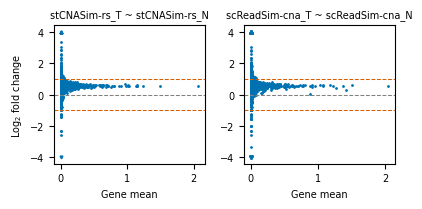

In [38]:
ncols = 2
fig, axs = plt.subplots(nrows = 1, ncols = ncols, figsize = (4.15, 2.2))

cut = (-4, 4)
cut_markers = ('v', '^')
fontsize = 7

gvars = selected_gvars.copy()
k = 0
for i in range(gvars.shape[0]):
    ax = axs[k]
    cx = gvars['x'].iloc[i]
    cy = gvars['y'].iloc[i]
    df = st_log2fc.loc[(st_log2fc['x'] == cx) & (st_log2fc['y'] == cy)].copy()

    vx = df['mean_x'].to_numpy()
    vy = df['log2FC'].to_numpy()
    vx = np.log10(vx + 1)

    low, high = cut
    x1 = vx[vy > high]
    y1 = np.repeat(high, len(x1))
    x2 = vx[np.logical_and(vy >= low, vy <= high)]
    y2 = vy[np.logical_and(vy >= low, vy <= high)]
    x3 = vx[vy < low]
    y3 = np.repeat(low, len(x3))
    
    ax.plot(x1, y1, marker = cut_markers[1], markersize = 2, 
            linestyle = 'none', color = def_color)
    ax.plot(x2, y2, marker = '.', markersize = 2, 
            linestyle = 'none', color = def_color)
    ax.plot(x3, y3, marker = cut_markers[0], markersize = 2, 
            linestyle = 'none', color = def_color)

    fc_kws = dict()
    ax.axhline(
        y = fc_kws.get('y_up', 1),
        linestyle = fc_kws.get('linestyle', '--'),
        linewidth = fc_kws.get('linewidth', 0.75),
        color = fc_kws.get('color', red)
    )
    ax.axhline(
        y = fc_kws.get('y_low', -1),
        linestyle = fc_kws.get('linestyle', '--'),
        linewidth = fc_kws.get('linewidth', 0.75),
        color = fc_kws.get('color', red)
    )

    ref_kws = dict()
    ax.axhline(
        y = ref_kws.get('y', 0), 
        linestyle = ref_kws.get('linestyle', '--'), 
        linewidth = ref_kws.get('linewidth', 0.75),
        color = ref_kws.get('color', 'gray')
    )
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(
        ax.get_xticklabels(), 
        fontsize = fontsize
    )
    ax.set_ylim(-4.4, 4.4)
    ax.set_yticks([-4, -2, 0, 2, 4])
    ax.set_yticklabels(
        ax.get_yticklabels(), 
        fontsize = fontsize
    )
    ax.set_xlabel("Gene mean", fontsize = fontsize)
    if k % ncols == 0:
        ax.set_ylabel(r"Log$_2$ fold change", fontsize = fontsize)
    ax.set_title(cy + ' ~ ' + cx, fontsize = fontsize)
    k += 1

for ax in axs:
    for s in ["top", "right"]:
        ax.spines[s].set_visible(True)
        
plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "log2fc-vs-mean.png")
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')